# COPC Access in R with `lasR` on MAAP — Previous Method vs Efficient COPC Method (Fixed lasR summarise)

## Dataset: MAAP `GEDI_CalVal_Lidar_COPC`

This notebook demonstrates **two approaches** for working with LiDAR COPC data on MAAP:

1. **Approach 1 — Previous method:** download the full point-cloud file first, then process it locally.
2. **Approach 2 — Efficient method:** read the cloud-hosted COPC file directly using `lasR` and GDAL VSI paths such as `/vsis3/` and `/vsicurl/`.

The goal is to show why COPC is useful for cloud workflows. With the previous method, the entire file is transferred before analysis. With the COPC method, MAAP can request only metadata or only a selected spatial area from the cloud-hosted point cloud.

> **Environment:** This notebook is intended for the MAAP Hub R `pyrocket-geospatial` workspace or another MAAP R workspace with `lasR`, GDAL, `sf`, `terra`, and `rstac` available.


## 1. Setup

This section loads the required R packages and sets GDAL environment options for remote cloud reads.

The GDAL VSI settings are most important for **Approach 2**, where the file is read directly from cloud storage.




In [1]:
# Load lasR and configure GDAL VSI settings
library(lasR)

cat("lasR version:", as.character(packageVersion("lasR")), "\n")
cat("lasR loaded OK\n")

# GDAL / VSI environment variables for public S3 and remote range reads
Sys.setenv(
  AWS_NO_SIGN_REQUEST                = "YES",
  GDAL_HTTP_MERGE_CONSECUTIVE_RANGES = "YES",
  CPL_VSIL_CURL_CHUNK_SIZE           = "1048576",
  CPL_VSIL_CURL_CACHE_SIZE           = "67108864",
  GDAL_HTTP_CONNECTTIMEOUT           = "30",
  GDAL_HTTP_TIMEOUT                  = "120"
)

cat("GDAL VSI environment variables set\n")


lasR version: 0.20.0 
lasR loaded OK
GDAL VSI environment variables set


In [26]:
# Install or verify supporting R packages
pkgs <- c("rstac", "sf", "terra", "ggplot2", "dplyr")
missing <- pkgs[!sapply(pkgs, requireNamespace, quietly = TRUE)]

if (length(missing) > 0) {
  install.packages(missing, repos = "https://cloud.r-project.org")
}

library(rstac)
library(sf)
library(terra)



## 2. Discover a COPC file from MAAP STAC

Both approaches use the same source data.

This section queries the MAAP STAC API for the `GEDI_CalVal_Lidar_COPC` collection, extracts a COPC asset URL, and prepares two forms of the path:

- **Download URL:** used by the previous method to download the complete file locally.
- **GDAL VSI URL:** used by the efficient method to read the COPC file directly from cloud storage.


In [3]:
# Query MAAP STAC for COPC items
`%||%` <- function(a, b) if (!is.null(a)) a else b

STAC_API   <- "https://stac.maap-project.org"
COLLECTION <- "GEDI_CalVal_Lidar_COPC"

items <- stac(STAC_API) |>
  collections(COLLECTION) |>
  items(limit = 10) |>
  get_request()

cat(sprintf("Collection:     %s\n", COLLECTION))
cat(sprintf("Items returned: %d\n", length(items$features)))

# Extract item ID, asset href, and bbox
item_info <- lapply(items$features, function(feat) {
  assets <- feat$assets
  href   <- assets$data$href %||% assets$copc$href %||% assets[[1]]$href
  list(id = feat$id, href = href, bbox = feat$bbox)
})

# Convert S3 or HTTPS URLs to GDAL VSI paths
build_vsi_uri <- function(href) {
  if (startsWith(href, "s3://")) {
    paste0("/vsis3/", sub("^s3://", "", href))
  } else if (startsWith(href, "https://")) {
    paste0("/vsicurl/", href)
  } else {
    href
  }
}

# Convert public S3 URL to HTTPS download URL for the previous method
s3_to_https <- function(href) {
  if (!startsWith(href, "s3://")) return(href)
  no_scheme <- sub("^s3://", "", href)
  bucket <- sub("/.*$", "", no_scheme)
  key <- sub("^[^/]+/", "", no_scheme)
  paste0("https://", bucket, ".s3.amazonaws.com/", key)
}

ALL_HREFS <- vapply(item_info, function(it) it$href, character(1))
ALL_URIS  <- vapply(ALL_HREFS, build_vsi_uri, character(1))

# Select one test item
TEST_ITEM <- item_info[[1]]
TEST_HREF <- TEST_ITEM$href
TEST_URI  <- build_vsi_uri(TEST_HREF)
TEST_DOWNLOAD_URL <- s3_to_https(TEST_HREF)

cat("\nSelected test item:\n")
cat("  ID:             ", TEST_ITEM$id, "\n")
cat("  Original href:  ", TEST_HREF, "\n")
cat("  Download URL:   ", TEST_DOWNLOAD_URL, "\n")
cat("  GDAL VSI path:  ", TEST_URI, "\n")


Collection:     GEDI_CalVal_Lidar_COPC
Items returned: 10

Selected test item:
  ID:              usa_tepeecreek_2809704010602 
  Original href:   s3://nasa-maap-data-store/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809704010602.copc.laz 
  Download URL:    https://nasa-maap-data-store.s3.amazonaws.com/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809704010602.copc.laz 
  GDAL VSI path:   /vsis3/nasa-maap-data-store/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809704010602.copc.laz 


# Approach 1 — Previous Method: Download Full File First, Then Process Locally

In the previous method, the complete `.copc.laz` or `.laz` file is downloaded into the MAAP workspace before any analysis is done.

This is simple and familiar, but it is not efficient for large LiDAR datasets because the entire file must be transferred even when the analysis only needs a small area.

**Workflow:**

1. Get the file URL from STAC.
2. Download the complete file to local storage.
3. Open the local file using `lasR`.
4. Run header summary or spatial subset operations on the local file.
5. Delete the local file if it is no longer needed.

> The code below uses a safety flag so the notebook does not accidentally download a large file. Set `RUN_FULL_DOWNLOAD <- TRUE` when you want to run this comparison.


In [14]:
# Approach 1 configuration
# Set this to TRUE when you want to demonstrate the previous full-download method.
RUN_FULL_DOWNLOAD <- TRUE

local_dir <- file.path(tempdir(), "maap_copc_download_demo")
dir.create(local_dir, showWarnings = FALSE, recursive = TRUE)

local_copc <- file.path(local_dir, basename(TEST_HREF))

cat("Previous-method local file path:\n")
cat(local_copc, "\n")
cat("\nRUN_FULL_DOWNLOAD is currently:", RUN_FULL_DOWNLOAD, "\n")


Previous-method local file path:
/tmp/Rtmpxw2pgF/maap_copc_download_demo/usa_tepeecreek_2809704010602.copc.laz 

RUN_FULL_DOWNLOAD is currently: TRUE 


In [15]:
# Approach 1A: Download the complete COPC file locally
if (RUN_FULL_DOWNLOAD) {
  cat("Downloading full COPC file...\n")
  cat("Source:     ", TEST_DOWNLOAD_URL, "\n")
  cat("Destination:", local_copc, "\n\n")
  
  t0 <- proc.time()
  download.file(TEST_DOWNLOAD_URL, destfile = local_copc, mode = "wb", quiet = FALSE)
  download_time <- (proc.time() - t0)["elapsed"]
  
  local_size_mb <- file.info(local_copc)$size / 1024^2
  cat(sprintf("\nDownload complete in %.1f seconds\n", download_time))
  cat(sprintf("Local file size: %.2f MB\n", local_size_mb))
} else {
  cat("Skipped full download. Set RUN_FULL_DOWNLOAD <- TRUE to run this cell.\n")
}


Source:      https://nasa-maap-data-store.s3.amazonaws.com/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809704010602.copc.laz 
Destination: /tmp/Rtmpxw2pgF/maap_copc_download_demo/usa_tepeecreek_2809704010602.copc.laz 


Download complete in 0.5 seconds
Local file size: 15.57 MB


In [16]:
# Approach 1B: Read the locally downloaded file with lasR
if (RUN_FULL_DOWNLOAD && file.exists(local_copc)) {
  cat("Reading local file header/summary after full download...\n")
  
  t0 <- proc.time()
  local_summary <- exec(reader(copc_depth = 0L) + lasR::summarise(), on = local_copc)
  local_header_time <- (proc.time() - t0)["elapsed"]
  
  cat(sprintf("Local header read complete in %.1f seconds\n", local_header_time))
  print(local_summary)
} else {
  cat("Local file is not available. Run the download cell first.\n")
}


Reading local file header/summary after full download...
Local header read complete in 0.1 seconds
$npoints
[1] 79321

$nsingle
[1] 31321

$nwithheld
[1] 0

$nsynthetic
[1] 0

$npoints_per_return
    1     2     3     4     5     6     7 
52327 19565  5977  1326   119     6     1 

$npoints_per_class
    1     2 
61277 18044 

$z_histogram
1360.000000 1362.000000 1364.000000 1366.000000 1368.000000 1370.000000 
         10          58          62         142         247         263 
1372.000000 1374.000000 1376.000000 1378.000000 1380.000000 1382.000000 
        422         596         587         768         927         788 
1384.000000 1386.000000 1388.000000 1390.000000 1392.000000 1394.000000 
       1113        1151        1098        1443        1745        1555 
1396.000000 1398.000000 1400.000000 1402.000000 1404.000000 1406.000000 
       1989        2055        1880        2333        2267        2127 
1408.000000 1410.000000 1412.000000 1414.000000 1416.000000 1418.000000 
 

In [17]:
# Approach 1C: Spatial subset after downloading the full file
# The subset is local, but the full file had to be downloaded first.
XMIN <- 558600; XMAX <- 558900
YMIN <- 5295200; YMAX <- 5295500

if (RUN_FULL_DOWNLOAD && file.exists(local_copc)) {
  cat("Reading 300 m x 300 m spatial subset from local file...\n")
  
  t0 <- proc.time()
  local_subset <- exec(
    reader_rectangles(
      xmin = XMIN, ymin = YMIN,
      xmax = XMAX, ymax = YMAX
    ) + lasR::summarise(),
    on = local_copc
  )
  local_subset_time <- (proc.time() - t0)["elapsed"]
  
  cat(sprintf("Local spatial subset complete in %.1f seconds\n", local_subset_time))
  print(local_subset)
} else {
  cat("Local file is not available. Run the download cell first.\n")
}


Reading 300 m x 300 m spatial subset from local file...
Local spatial subset complete in 1.8 seconds
$npoints
[1] 1409855

$nsingle
[1] 765139

$nwithheld
[1] 0

$nsynthetic
[1] 0

$npoints_per_return
      1       2       3       4       5       6       7 
1040208  275180   79544   13632    1245      44       2 

$npoints_per_class
     1      2 
862168 547687 

$z_histogram
1360.000000 1362.000000 1364.000000 1366.000000 1368.000000 1370.000000 
        472        3154        4336        3330        4334        5234 
1372.000000 1374.000000 1376.000000 1378.000000 1380.000000 1382.000000 
       5488        8750       11883       13619       15363       15590 
1384.000000 1386.000000 1388.000000 1390.000000 1392.000000 1394.000000 
      17637       18898       21239       27806       32482       34852 
1396.000000 1398.000000 1400.000000 1402.000000 1404.000000 1406.000000 
      36783       38385       40016       40424       41100       44719 
1408.000000 1410.000000 1412.000000 1

## Interpretation of Approach 1

This method is useful as a baseline because it shows the older pattern:

> **Transfer the whole point cloud first, then process it.**

Even when the analysis only needs a 300 m × 300 m region, the full file is still downloaded before the subset can be read. For large LiDAR collections, this creates extra transfer time, storage use, and repeated I/O.


# Approach 2 — Efficient Method: Read Remote COPC Directly with `lasR`

In the efficient method, the COPC file stays in cloud storage. `lasR` reads it using a GDAL VSI path such as `/vsis3/...`.

This method is more efficient because COPC is spatially indexed. Instead of downloading the full file, `lasR` can request only the header or the selected spatial region.

**Workflow:**

1. Get the COPC asset URL from STAC.
2. Convert the cloud URL to a GDAL VSI path.
3. Read header metadata using `copc_depth = 0L`.
4. Read only the required spatial subset using `reader_rectangles()`.
5. Generate derived products such as DTM and CHM from the subset.


In [18]:
# Approach 2A: Header-only read directly from remote COPC
cat("Remote COPC path:\n")
cat(TEST_URI, "\n\n")

cat("Reading header only from remote COPC...\n")
t0 <- proc.time()
remote_header <- exec(reader(copc_depth = 0L) + lasR::summarise(), on = TEST_URI)
remote_header_time <- (proc.time() - t0)["elapsed"]

cat(sprintf("Remote header read complete in %.1f seconds\n", remote_header_time))
print(remote_header)


Remote COPC path:
/vsis3/nasa-maap-data-store/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809704010602.copc.laz 

Reading header only from remote COPC...
Remote header read complete in 0.1 seconds
$npoints
[1] 79321

$nsingle
[1] 31321

$nwithheld
[1] 0

$nsynthetic
[1] 0

$npoints_per_return
    1     2     3     4     5     6     7 
52327 19565  5977  1326   119     6     1 

$npoints_per_class
    1     2 
61277 18044 

$z_histogram
1360.000000 1362.000000 1364.000000 1366.000000 1368.000000 1370.000000 
         10          58          62         142         247         263 
1372.000000 1374.000000 1376.000000 1378.000000 1380.000000 1382.000000 
        422         596         587         768         927         788 
1384.000000 1386.000000 1388.000000 1390.000000 1392.000000 1394.000000 
       1113        1151        1098        1443        1745        1555 
1396.000000 1398.000000 1400.000000 1402.000000 1404.000000 1406.000000 
       1989        2055        1

In [19]:
# Extract projected CRS EPSG from the header when possible
# Some compound CRS strings return EPSG 0 directly, so this parses the projected CRS block.
wkt <- remote_header$crs

projcs_block <- tryCatch(
  sub(".*?(PROJCS\\[.*?\\]),VERT_CS.*", "\\1", wkt, perl = TRUE),
  error = function(e) NA_character_
)

epsg_hits <- tryCatch(
  regmatches(
    projcs_block,
    gregexpr('(?<=AUTHORITY\\["EPSG",")\\d+(?="\\])', projcs_block, perl = TRUE)
  )[[1]],
  error = function(e) character(0)
)

TILE_EPSG <- if (length(epsg_hits) > 0) as.integer(tail(epsg_hits, 1)) else NA_integer_

cat("Projected CRS EPSG:", TILE_EPSG, "\n")
if (!is.na(TILE_EPSG)) {
  cat("CRS name:", sf::st_crs(TILE_EPSG)$Name, "\n")
}


Projected CRS EPSG: 3741 
CRS name: NAD83(HARN) / UTM zone 11N 


In [20]:
# Approach 2B: Spatial subset directly from remote COPC
# This reads only the selected window from the cloud-hosted COPC.
XMIN <- 558600; XMAX <- 558900
YMIN <- 5295200; YMAX <- 5295500

cat("Reading 300 m x 300 m subset directly from remote COPC...\n")

t0 <- proc.time()
remote_subset <- exec(
  reader_rectangles(
    xmin = XMIN, ymin = YMIN,
    xmax = XMAX, ymax = YMAX
  ) + lasR::summarise(),
  on = TEST_URI
)
remote_subset_time <- (proc.time() - t0)["elapsed"]

cat(sprintf("Remote spatial subset complete in %.1f seconds\n", remote_subset_time))
print(remote_subset)


Reading 300 m x 300 m subset directly from remote COPC...
Remote spatial subset complete in 1.9 seconds
$npoints
[1] 1409855

$nsingle
[1] 765139

$nwithheld
[1] 0

$nsynthetic
[1] 0

$npoints_per_return
      1       2       3       4       5       6       7 
1040208  275180   79544   13632    1245      44       2 

$npoints_per_class
     1      2 
862168 547687 

$z_histogram
1360.000000 1362.000000 1364.000000 1366.000000 1368.000000 1370.000000 
        472        3154        4336        3330        4334        5234 
1372.000000 1374.000000 1376.000000 1378.000000 1380.000000 1382.000000 
       5488        8750       11883       13619       15363       15590 
1384.000000 1386.000000 1388.000000 1390.000000 1392.000000 1394.000000 
      17637       18898       21239       27806       32482       34852 
1396.000000 1398.000000 1400.000000 1402.000000 1404.000000 1406.000000 
      36783       38385       40016       40424       41100       44719 
1408.000000 1410.000000 1412.00000

In [21]:
# Optional: Full remote summary for comparison
# This may be slower because it asks lasR to summarize the full remote file.
RUN_FULL_REMOTE_SUMMARY <- FALSE

if (RUN_FULL_REMOTE_SUMMARY) {
  cat("Running full remote summary. This may take longer.\n")
  
  t0 <- proc.time()
  remote_full <- exec(reader() + lasR::summarise(), on = TEST_URI)
  remote_full_time <- (proc.time() - t0)["elapsed"]
  
  cat(sprintf("Full remote summary complete in %.1f seconds\n", remote_full_time))
  print(remote_full)
  
  if (exists("remote_subset") && !is.null(remote_subset$npoints) && !is.null(remote_full$npoints)) {
    cat(sprintf(
      "Fraction of file represented by subset: %.4f%%\n",
      100 * remote_subset$npoints / remote_full$npoints
    ))
  }
} else {
  cat("Skipped full remote summary. Set RUN_FULL_REMOTE_SUMMARY <- TRUE if needed.\n")
}


Skipped full remote summary. Set RUN_FULL_REMOTE_SUMMARY <- TRUE if needed.


## Interpretation of Approach 2

This method demonstrates the cloud-optimized workflow:

> **Keep the point cloud in cloud storage and read only what is needed.**

The header read checks the file without transferring the entire point cloud. The spatial subset read shows how `lasR` can access only the selected region from the remote COPC file. This is the key advantage over the previous full-download method.


# Approach 2C — Derived Products from Remote COPC Subset

After the efficient spatial read, the same subset can be used to create analysis products such as:

- **DTM:** Digital Terrain Model
- **CHM:** Canopy Height Model

These products are generated from the selected remote COPC window instead of from a full downloaded point cloud.


Computing DTM from remote COPC subset...
Output: /tmp/Rtmpxw2pgF/usa_tepeecreek_2809704010602_dtm.tif 



class       : SpatRaster 
size        : 290, 301, 1  (nrow, ncol, nlyr)
resolution  : 1, 1  (x, y)
extent      : 558600, 558901, 5295211, 5295501  (xmin, xmax, ymin, ymax)
coord. ref. : NAD83(HARN) / UTM zone 11N (EPSG:3741) 
source      : usa_tepeecreek_2809704010602_dtm.tif 
name        : max 


DTM completed in 2.6 seconds
class       : SpatRaster 
size        : 289, 300, 1  (nrow, ncol, nlyr)
resolution  : 1, 1  (x, y)
extent      : 558600, 558900, 5295211, 5295500  (xmin, xmax, ymin, ymax)
coord. ref. : NAD83(HARN) / UTM zone 11N (EPSG:3741) 
source(s)   : memory
varname     : usa_tepeecreek_2809704010602_dtm 
name        :     max 
min value   : 1361.23 
max value   : 1488.53 


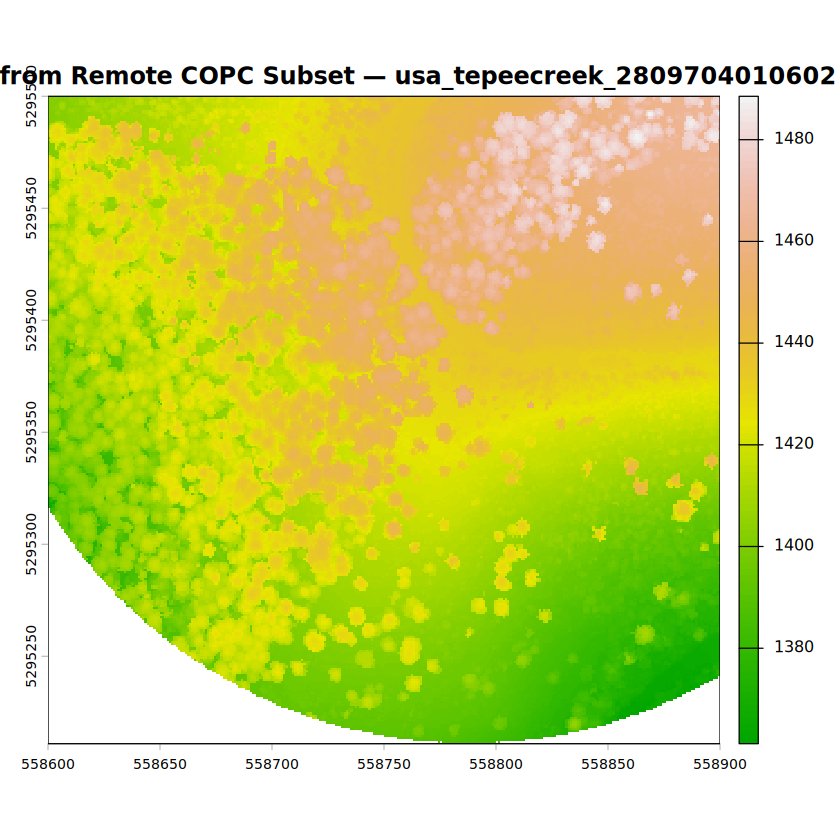

In [22]:
# DTM from remote COPC subset
library(lasR)
library(terra)

XMIN <- 558600; XMAX <- 558900
YMIN <- 5295200; YMAX <- 5295500

dtm_out <- file.path(tempdir(), paste0(TEST_ITEM$id, "_dtm.tif"))
cat("Computing DTM from remote COPC subset...\n")
cat("Output:", dtm_out, "\n\n")

t0 <- proc.time()
pipeline_dtm <- reader_rectangles(
    xmin = XMIN, ymin = YMIN,
    xmax = XMAX, ymax = YMAX,
    copc_depth = NULL
  ) +
  triangulate(filter = keep_ground()) +
  lasR::rasterize(res = 1, method = "tin", ofile = dtm_out)

exec(pipeline_dtm, on = TEST_URI)
cat(sprintf("\nDTM completed in %.1f seconds\n", (proc.time() - t0)["elapsed"]))

if (file.exists(dtm_out)) {
  dtm <- terra::rast(dtm_out)
  dtm <- terra::crop(dtm, terra::ext(XMIN, XMAX, YMIN, YMAX))
  print(dtm)
  terra::plot(
    dtm,
    main   = paste0("DTM from Remote COPC Subset — ", TEST_ITEM$id),
    col    = terrain.colors(100),
    axes   = TRUE,
    legend = TRUE
  )
}


Computing CHM from remote COPC subset...
Output: /tmp/Rtmpxw2pgF/usa_tepeecreek_2809704010602_chm.tif 



class       : SpatRaster 
size        : 578, 601, 1  (nrow, ncol, nlyr)
resolution  : 0.5, 0.5  (x, y)
extent      : 558600, 558900.5, 5295212, 5295500  (xmin, xmax, ymin, ymax)
coord. ref. : NAD83(HARN) / UTM zone 11N (EPSG:3741) 
source      : usa_tepeecreek_2809704010602_chm.tif 
name        : max 


CHM completed in 3.3 seconds
class       : SpatRaster 
size        : 577, 600, 1  (nrow, ncol, nlyr)
resolution  : 0.5, 0.5  (x, y)
extent      : 558600, 558900, 5295212, 5295500  (xmin, xmax, ymin, ymax)
coord. ref. : NAD83(HARN) / UTM zone 11N (EPSG:3741) 
source(s)   : memory
varname     : usa_tepeecreek_2809704010602_chm 
name        :   max 
min value   : -0.43 
max value   : 41.08 


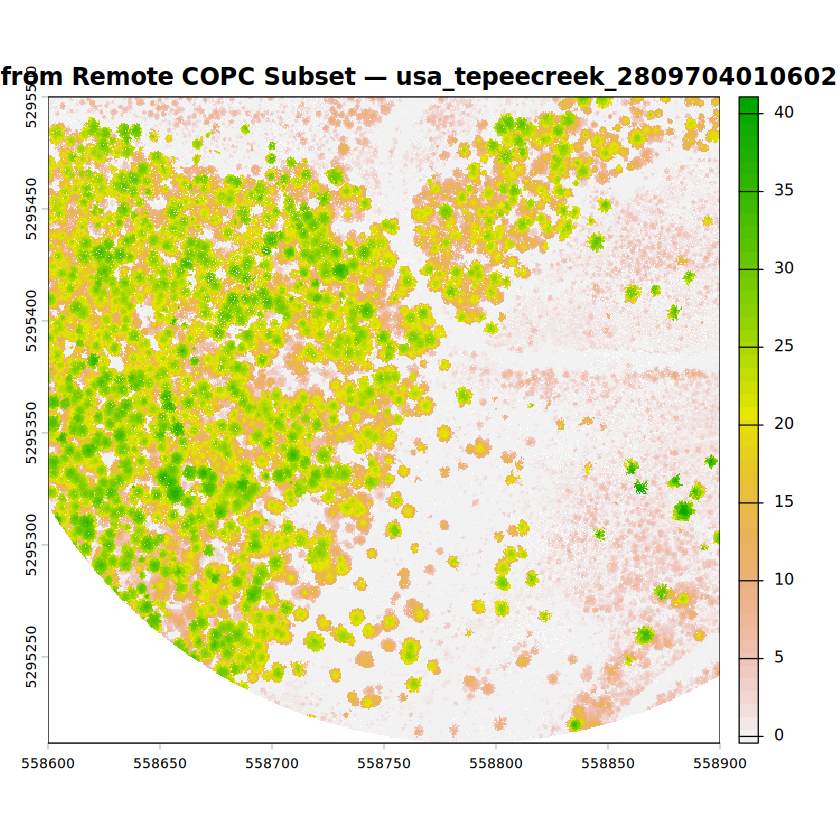

In [23]:
# CHM from remote COPC subset
library(lasR)
library(terra)

XMIN <- 558600; XMAX <- 558900
YMIN <- 5295200; YMAX <- 5295500

chm_out <- file.path(tempdir(), paste0(TEST_ITEM$id, "_chm.tif"))
cat("Computing CHM from remote COPC subset...\n")
cat("Output:", chm_out, "\n\n")

t0 <- proc.time()
ground_tri <- triangulate(filter = keep_ground())

pipeline_chm <- reader_rectangles(
    xmin = XMIN, ymin = YMIN,
    xmax = XMAX, ymax = YMAX,
    copc_depth = NULL
  ) +
  ground_tri +
  transform_with(ground_tri) +
  lasR::rasterize(res = 0.5, method = "max", ofile = chm_out)

exec(pipeline_chm, on = TEST_URI)
cat(sprintf("\nCHM completed in %.1f seconds\n", (proc.time() - t0)["elapsed"]))

if (file.exists(chm_out)) {
  chm <- terra::rast(chm_out)
  chm <- terra::crop(chm, terra::ext(XMIN, XMAX, YMIN, YMAX))
  print(chm)
  terra::plot(
    chm,
    main   = paste0("CHM from Remote COPC Subset — ", TEST_ITEM$id),
    col    = rev(terrain.colors(50)),
    axes   = TRUE,
    legend = TRUE
  )
}


# Multi-File Remote COPC Catalogue Pattern

The efficient method also scales better to multiple files. Instead of downloading many point-cloud tiles, we can pass a vector of remote GDAL VSI paths to `lasR` and process each one.

This is the pattern that is most useful for MAAP-scale workflows.


In [24]:
# Process a small catalogue of remote COPC files
# Uses low-resolution COPC depth for a faster catalogue-level summary.
test_uris <- ALL_URIS[1:min(3, length(ALL_URIS))]
cat(sprintf("Processing %d remote COPC tiles...\n", length(test_uris)))

t0 <- proc.time()
pipeline_cat <- reader(copc_depth = 2L) + lasR::summarise()

results_cat <- lapply(seq_along(test_uris), function(i) {
  u <- test_uris[i]
  cat(sprintf("  [%d/%d] %s\n", i, length(test_uris), basename(u)))
  tryCatch(
    exec(pipeline_cat, on = u),
    error = function(e) {
      cat("    ERROR:", conditionMessage(e), "\n")
      NULL
    }
  )
})

cat(sprintf("\nCatalogue processing done in %.1f seconds\n", (proc.time() - t0)["elapsed"]))

cat("\nPer-tile summary:\n")
for (i in seq_along(results_cat)) {
  r <- results_cat[[i]]
  if (!is.null(r)) {
    cat(sprintf(
      "  %-50s %s pts\n",
      item_info[[i]]$id,
      format(r$npoints, big.mark = ",")
    ))
  }
}


Processing 3 remote COPC tiles...
  [1/3] usa_tepeecreek_2809704010602.copc.laz
  [2/3] usa_tepeecreek_2809702010602.copc.laz
  [3/3] usa_tepeecreek_2809700010602.copc.laz

Catalogue processing done in 6.1 seconds

Per-tile summary:
  usa_tepeecreek_2809704010602                       1,509,730 pts
  usa_tepeecreek_2809702010602                       1,619,214 pts
  usa_tepeecreek_2809700010602                       1,438,897 pts


# Final Comparison

| Step | Approach 1: Previous Method | Approach 2: Efficient COPC Method |
|---|---|---|
| File access | Download full file first | Read remote COPC directly |
| Local storage | Requires local copy | No full local copy required |
| Subsetting | Done after full file transfer | Done during remote read |
| Data transfer | Higher | Lower |
| Best use | Small local files or one-time testing | Large cloud-hosted LiDAR workflows |
| MAAP value | Works, but less scalable | Better suited for cloud-native processing |

**Main takeaway:**

The previous method downloads the complete point cloud before processing. The efficient COPC method keeps the file in cloud storage and reads only the metadata or spatial region needed for the analysis.


In [25]:
# Diagnostics: environment snapshot for reproducibility
cat("============================================================\n")
cat("lasR COPC/VSI Diagnostics — MAAP GEDI CalVal Dataset\n")
cat("============================================================\n")
cat("Timestamp:     ", format(Sys.time()), "\n")
cat("R version:     ", R.version$version.string, "\n")
cat("lasR version:  ", as.character(packageVersion("lasR")), "\n")
cat("Platform:      ", R.version$platform, "\n")
cat("GDAL version:  ", tryCatch(system("gdal-config --version", intern = TRUE), error = function(e) "not available"), "\n")
cat("terra version: ", as.character(packageVersion("terra")), "\n")
cat("sf version:    ", as.character(packageVersion("sf")), "\n")
cat("rstac version: ", as.character(packageVersion("rstac")), "\n")

cat("\nVSI ENV:\n")
for (v in c(
  "AWS_NO_SIGN_REQUEST",
  "GDAL_HTTP_MERGE_CONSECUTIVE_RANGES",
  "CPL_VSIL_CURL_CHUNK_SIZE",
  "CPL_VSIL_CURL_CACHE_SIZE",
  "GDAL_HTTP_TIMEOUT"
)) {
  cat(sprintf("  %-40s = %s\n", v, Sys.getenv(v, "(not set)")))
}

cat("\nTest item:       ", TEST_ITEM$id, "\n")
cat("Original href:   ", TEST_HREF, "\n")
cat("Download URL:    ", TEST_DOWNLOAD_URL, "\n")
cat("GDAL VSI path:   ", TEST_URI, "\n")
cat("TILE_EPSG:       ", TILE_EPSG, "\n")
cat("============================================================\n")


lasR COPC/VSI Diagnostics — MAAP GEDI CalVal Dataset
Timestamp:      2026-05-13 16:44:13 
R version:      R version 4.5.1 (2025-06-13) 
lasR version:   0.20.0 
Platform:       x86_64-pc-linux-gnu 
GDAL version:   3.8.4 
terra version:  1.9.11 
sf version:     1.1.0 
rstac version:  1.0.1 

VSI ENV:
  AWS_NO_SIGN_REQUEST                      = YES
  GDAL_HTTP_MERGE_CONSECUTIVE_RANGES       = YES
  CPL_VSIL_CURL_CHUNK_SIZE                 = 1048576
  CPL_VSIL_CURL_CACHE_SIZE                 = 67108864
  GDAL_HTTP_TIMEOUT                        = 120

Test item:        usa_tepeecreek_2809704010602 
Original href:    s3://nasa-maap-data-store/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809704010602.copc.laz 
Download URL:     https://nasa-maap-data-store.s3.amazonaws.com/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809704010602.copc.laz 
GDAL VSI path:    /vsis3/nasa-maap-data-store/file-staging/nasa-map/GEDI_CalVal_Lidar_COPC/usa_tepeecreek_2809704010602.c